# Regresión con Keras

En este laboratorio vamos a utilizar Keras para construir dos modelos de Regresión mediante Redes Neuronales y comparar sus resultados.

### SETUP

In [9]:
!pip install -q numpy==2.0.2
!pip install -q pandas==2.2.2
!pip install -q tensorflow_cpu==2.18.0
!pip install -q matplotlib

In [10]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import pandas as pd
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter('ignore', FutureWarning)




## Dataset

Nuestro dataset contiene información sobre la fuerza de diferentes tipos de concreto basandose en las cantidades de ingredientes. <br>

Descarguemos el dataset, definamos la variable objetivo y normalicemos los valores de los features.


In [ ]:
#Import Dataset
filepath='https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0101EN/labs/data/concrete_data.csv'
data = pd.read_csv(filepath)

#Feature/Target definition
predictors = data.drop(axis=1, labels="Strength")
target = data["Strength"]

#Normalization
predictors = (predictors - predictors.mean()) / predictors.std()

## Creación del Modelo

Ahora podemos pasar a la creación del modelo, recordemos que nuestro modelo debe tomar un arreglo de dimensión $N \times 1$ donde $N$ es la cantidad de features. <br> A fin de hacer que sea mas informativo este notebook voy a agregar un modelo más profundo para comprar las métricas obtenidas por ambos.

In [ ]:
#Define input array dimensions
feature_amnt = predictors.shape[1]
input_array_shape = (feature_amnt,) 

#Shallow model
shallow_regression_model = Sequential()
shallow_regression_model.add(Input(shape=input_array_shape))
shallow_regression_model.add(Dense(50, activation='relu'))
shallow_regression_model.add(Dense(50, activation='relu'))
shallow_regression_model.add(Dense(1))

#Compile the shallow model
shallow_regression_model.compile(optimizer='adam', loss='mean_squared_error')

#Deep model
deep_regression_model = Sequential()
deep_regression_model.add(Input(shape=input_array_shape))  
for i in range(5): deep_regression_model.add(Dense(50, activation='relu'))  
deep_regression_model.add(Dense(1))  # Output layer
    
# compile the deep model
deep_regression_model.compile(optimizer='adam', loss='mean_squared_error')


Ahora entrenemos al modelo y obtengamos las predicciones, además vamos a retener la información de cada epoch para poder visualizar algunos resultados

In [20]:
shallow_history = shallow_regression_model.fit(predictors, target, validation_split=0.3, epochs=100, verbose=0)
deep_history = deep_regression_model.fit(predictors, target, validation_split=0.3, epochs=100, verbose=0)

Algo interesante para visualizar es el progreso de los valores de perdida, tanto en entrenamiento como validación 

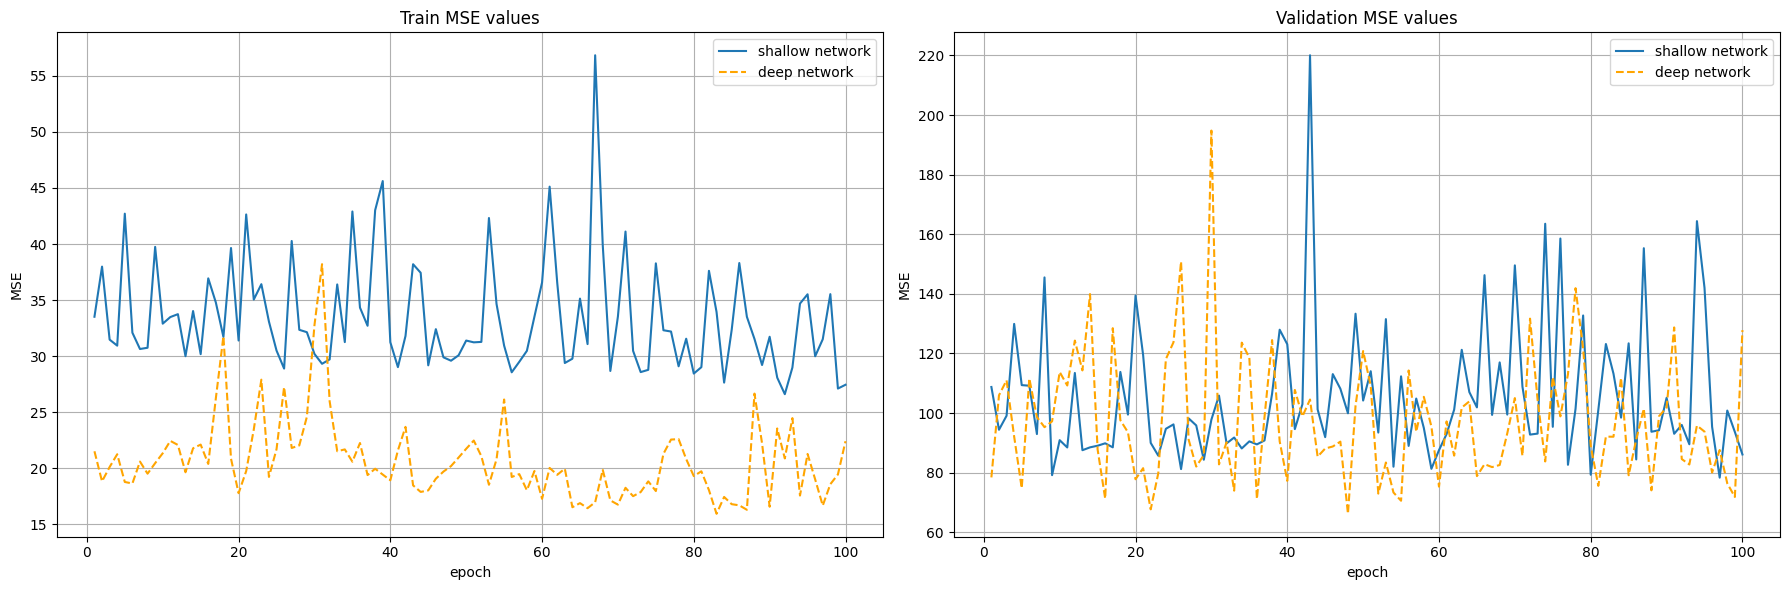

In [ ]:
#MSE values as arrays for shallow & deep networks
shallow_train_mse_history = shallow_history.history['loss']
shallow_val_mse_history = shallow_history.history['val_loss']
deep_train_mse_history = deep_history.history['loss']
deep_val_mse_history = deep_history.history['val_loss']

epochs = np.arange(1,101)

#Plotting
plt.figure(figsize=(18, 6))

#Train MSE plot
ax = plt.subplot(1, 2, 1)
ax.plot(epochs,shallow_train_mse_history, label="shallow network")
ax.plot(epochs,deep_train_mse_history, linestyle="--", color="orange", label="deep network")
ax.set(xlabel="epoch", ylabel="MSE", title="Train MSE values")
ax.legend()
ax.grid()

#Validation MSE plot
ax2 = plt.subplot(1, 2, 2)
ax2.plot(epochs,shallow_val_mse_history, label="shallow network")
ax2.plot(epochs,deep_val_mse_history, linestyle="--", color="orange", label="deep network")
ax2.set(xlabel="epoch", ylabel="MSE", title="Validation MSE values")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()



En este caso podemos ver como una red neuronal mas profunda sí hace una diferencia en la precisión del modelo. Dicho esto, es importante recordar que una red neuronal más profunda trae consigo una serie de complicaciones, en particular tiempos y costos computacionales que si bien en esta escala son despreciables pueden causar complicaciones en aplicaciones reales.